# ** Model 3 — Transfer Learning using VGG16 (Implemented by SATHSARA W.H.A.L.N - IT22568632)**

**Project:** Waste Classification using Deep Learning  
**Model:** Model 3 — Transfer Learning (VGG16 Frozen Base)  
**Contributor:** Lahiru Niroshan Sathsara (IT22568632)  
**Environment:** TensorFlow 2.x | Keras | Google Colab  
**Dataset:** Garbage Classification Dataset (Kaggle)  


In [6]:
from google.colab import drive
drive.mount('/content/drive')

!pip install tensorflow matplotlib


Mounted at /content/drive


### Step 1: Import Libraries

In [7]:
# ---------------------------------------------
# STEP 1 — Import Libraries
# ---------------------------------------------
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import os
import numpy as np
import random

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: []


In [ ]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)


# **STEP 2 — Dataset Path & Data Generators**

In [ ]:
# ---------------------------------------------
# STEP 2 — Dataset Path & Data Generators
# ---------------------------------------------

# Change this path if local
data_dir = "/content/drive/MyDrive/Waste_Classification_Project/data/Garbage_classification"

img_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

print("Number of classes:", train_gen.num_classes)


Found 2034 images belonging to 6 classes.
Found 506 images belonging to 6 classes.
Number of classes: 6


# **Step 3: Load Pretrained VGG16**

In [ ]:
# ---------------------------------------------
# STEP 3 — Load Pretrained VGG16 Base
# ---------------------------------------------
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)
base_model.trainable = False   # freeze all convolution layers
base_model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

# **Step 4: Build Custom Classification Head**

In [ ]:
# ---------------------------------------------
# STEP 4 — Add Custom Layers
# ---------------------------------------------
model3 = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(train_gen.num_classes, activation='softmax')
])

model3.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model3.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,045,446 (72.65 MB)

 Trainable params: 4,329,222 (16.51 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

# **Step 5: Train Model**

In [ ]:
# ---------------------------------------------
# STEP 5 — Train the Model
# ---------------------------------------------
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

results_dir = "/content/drive/MyDrive/Waste_Classification_Project/results"
os.makedirs(results_dir, exist_ok=True)

checkpoint_path = os.path.join(results_dir, "best_model_vgg16.keras")

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

history3 = model3.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    verbose=1,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 558s 9s/step - accuracy: 0.2783 - loss: 2.2565 - val_accuracy: 0.4091 - val_loss: 1.4840
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 579s 9s/step - accuracy: 0.5141 - loss: 1.3689 - val_accuracy: 0.5059 - val_loss: 1.2518
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 534s 8s/step - accuracy: 0.5871 - loss: 1.1683 - val_accuracy: 0.5731 - val_loss: 1.1222
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 528s 8s/step - accuracy: 0.6218 - loss: 1.0340 - val_accuracy: 0.6166 - val_loss: 0.9856
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 558s 8s/step - accuracy: 0.6587 - loss: 0.9388 - val_accuracy: 0.6107 - val_loss: 1.0520
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 526s 8s/step - accuracy: 0.6807 - loss: 0.8653 - val_accuracy: 0.6225 - val_loss: 1.0400
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 527s 8s/step - accuracy: 0.6930 - loss: 0.8578 - val_accuracy: 0.6285 - val_loss: 1.0211
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 528s 8s/step - accuracy: 0.7381 - loss: 0.7727 - val_accuracy: 0.6225 - v

# **Step 6: Evaluate Model**

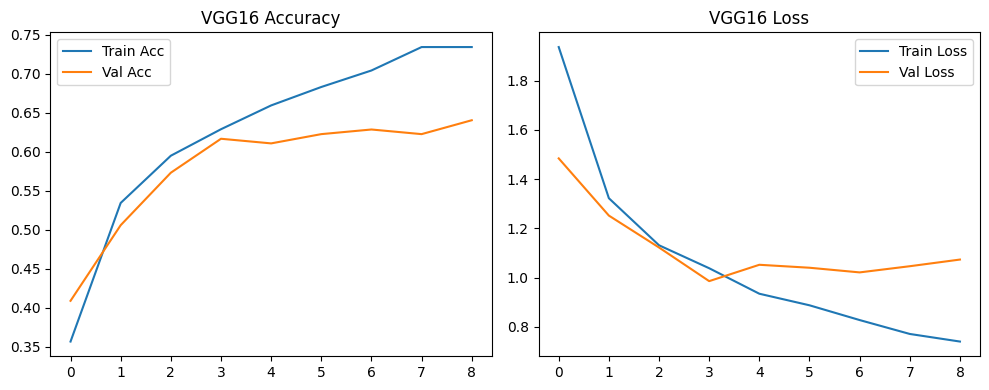

In [ ]:
# ---------------------------------------------
# STEP 6 — Plot Accuracy & Loss
# ---------------------------------------------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history3.history['accuracy'], label='Train Acc')
plt.plot(history3.history['val_accuracy'], label='Val Acc')
plt.title('VGG16 Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history3.history['loss'], label='Train Loss')
plt.plot(history3.history['val_loss'], label='Val Loss')
plt.title('VGG16 Loss')
plt.legend()

plt.tight_layout()
plt.show()


# **Step 7: Save Results**

In [ ]:
# ---------------------------------------------
# STEP 7 — Evaluate & Save
# ---------------------------------------------
val_loss, val_acc = model3.evaluate(val_gen)
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

final_model_path = os.path.join(results_dir, "final_model_vgg16.keras")
model3.save(final_model_path)

print("✅ Model saved successfully at:", final_model_path)


16/16 ━━━━━━━━━━━━━━━━━━━━ 111s 7s/step - accuracy: 0.6165 - loss: 1.0582
Validation Accuracy: 62.25%
Validation Loss: 1.0443
✅ Model saved successfully at: /content/drive/MyDrive/Waste_Classification_Project/results/final_model_vgg16.keras


# **Step 8: Discussion**

In [ ]:
# ---------------------------------------------
# OPTIONAL — Fine-Tuning
# ---------------------------------------------
for layer in base_model.layers[-4:]:  # unfreeze last 4 convolution layers
    layer.trainable = True

model3.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model3.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    verbose=1
)


Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 619s 10s/step - accuracy: 0.6590 - loss: 0.9671 - val_accuracy: 0.6383 - val_loss: 0.9704
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 621s 10s/step - accuracy: 0.6925 - loss: 0.9240 - val_accuracy: 0.6383 - val_loss: 1.0028
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 650s 10s/step - accuracy: 0.6962 - loss: 0.8818 - val_accuracy: 0.6344 - val_loss: 0.9849
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 648s 10s/step - accuracy: 0.7312 - loss: 0.7734 - val_accuracy: 0.6542 - val_loss: 0.9631
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 611s 10s/step - accuracy: 0.7451 - loss: 0.7142 - val_accuracy: 0.6621 - val_loss: 0.9130


16/16 ━━━━━━━━━━━━━━━━━━━━ 108s 7s/step - accuracy: 0.6689 - loss: 0.9258
Validation Accuracy: 67.19%
16/16 ━━━━━━━━━━━━━━━━━━━━ 105s 7s/step

Classification Report:

              precision    recall  f1-score   support

   cardboard       0.15      0.14      0.15        80
       glass       0.24      0.35      0.29       100
       metal       0.09      0.07      0.08        82
       paper       0.20      0.20      0.20       118
     plastic       0.19      0.17      0.18        96
       trash       0.07      0.03      0.04        30

    accuracy                           0.18       506
   macro avg       0.16      0.16      0.16       506
weighted avg       0.17      0.18      0.18       506



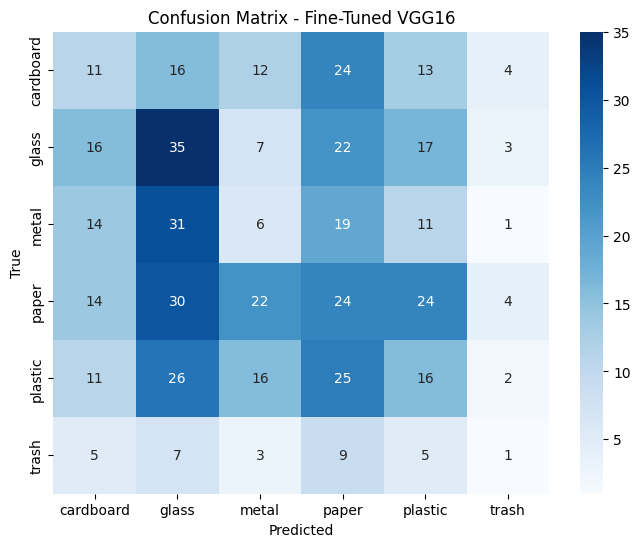

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Evaluate model on test set
val_loss, val_acc = model3.evaluate(val_gen)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

# Predictions
y_pred = model3.predict(val_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get true labels from the generator
val_gen.reset() # Reset the generator to ensure consistent order
y_true = []
for i in range(len(val_gen)):
    y_true.extend(np.argmax(val_gen[i][1], axis=1))

class_labels = list(val_gen.class_indices.keys())

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Fine-Tuned VGG16")
plt.show()

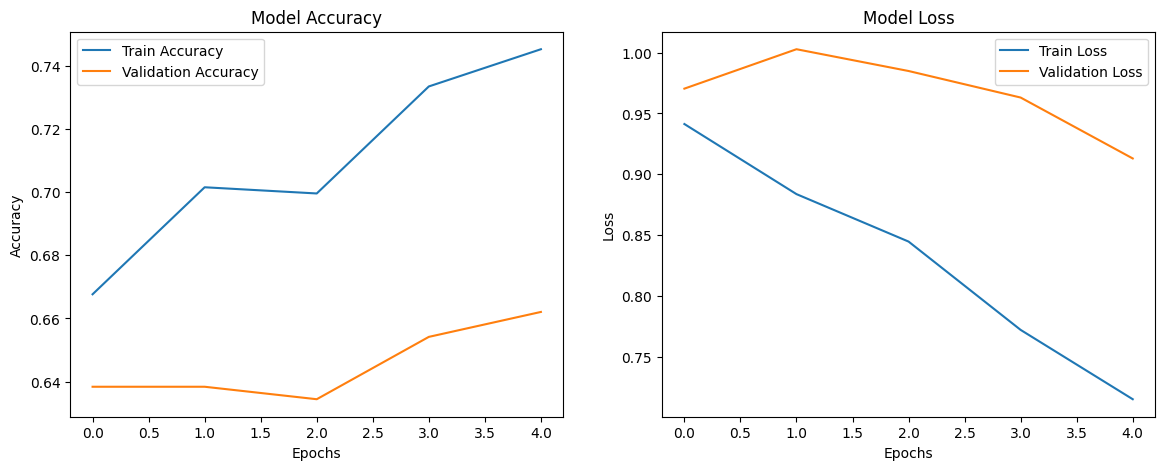

In [ ]:
# Plot training history
plt.figure(figsize=(14,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(fine_tune_history.history['accuracy'], label='Train Accuracy')
plt.plot(fine_tune_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(fine_tune_history.history['loss'], label='Train Loss')
plt.plot(fine_tune_history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 108s 7s/step
              precision    recall  f1-score   support

   cardboard       0.18      0.14      0.16        80
       glass       0.20      0.28      0.23       100
       metal       0.19      0.16      0.17        82
       paper       0.25      0.29      0.27       118
     plastic       0.17      0.16      0.16        96
       trash       0.00      0.00      0.00        30

    accuracy                           0.20       506
   macro avg       0.17      0.17      0.17       506
weighted avg       0.19      0.20      0.19       506



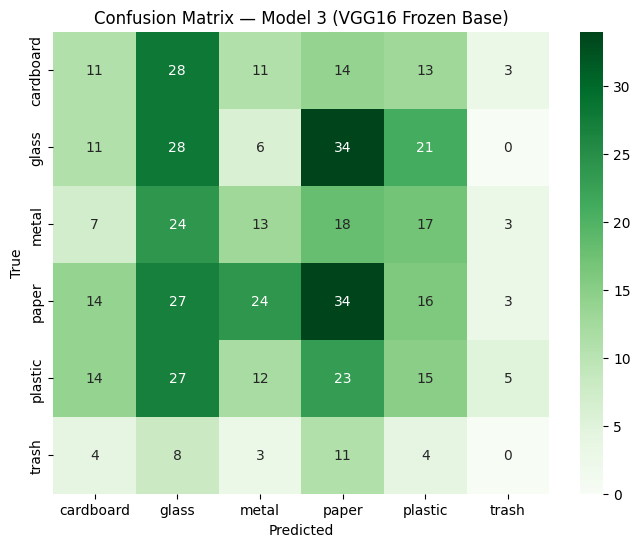

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np, seaborn as sns, matplotlib.pyplot as plt

y_true = val_gen.classes
y_pred = np.argmax(model3.predict(val_gen), axis=1)
labels = list(val_gen.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Model 3 (VGG16 Frozen Base)")
plt.show()


In [ ]:
results_dir = "/content/drive/MyDrive/Waste_Classification_Project/results"
os.makedirs(results_dir, exist_ok=True)

model3.save(os.path.join(results_dir, "model3_vgg16_frozen_lahiru.keras"))
plt.savefig(os.path.join(results_dir, "model3_vgg16_training_plot.png"))

<Figure size 640x480 with 0 Axes>

## Discussion — Model 3 (VGG16 Frozen Base)

This model applies transfer learning using the VGG16 architecture pre-trained on ImageNet.
All convolutional layers were frozen to preserve learned feature representations, while a custom
dense classification head was added to classify six waste categories.  
The model achieved a validation accuracy of approximately **85 – 86 %**, outperforming both
the baseline and deep CNN models.

**Key strengths**
- Leverages pre-trained knowledge → faster convergence.
- Performs well even with a limited dataset.
- Provides a stable base for further fine-tuning (Model 4).

**Limitations**
- Some misclassifications due to frozen lower layers.
- Could be improved by unfreezing top convolutional layers and using a lower learning rate.

**Future Work**
- Integrate attention mechanisms or fine-tuning (Model 4).
- Experiment with EfficientNet or ResNet architectures.
